# Extracting temperature data from ERA5

In [1]:
import xarray as xr
import pandas as pd
from pathlib import Path

In [3]:
lonlat = pd.read_csv('../data/raw/locations.csv')

## Max temp

In [2]:
files = sorted(Path("../data/raw/chirts/chirts_max").glob("chirts_tmax_*.nc"))

ds_max = xr.open_mfdataset(
    files,
    engine="netcdf4",
    combine="by_coords",
    parallel=False
)

In [7]:
points = lonlat.reset_index(drop=True)

lons = xr.DataArray(points.lon.values, dims="points")
lats = xr.DataArray(points.lat.values, dims="points")

tmax = ds_max["temp"].sel(
    longitude=lons,
    latitude=lats,
    method="nearest"
) 

In [11]:
tmax.to_dataframe().isnull().sum()

latitude         0
longitude        0
temp         20733
dtype: int64

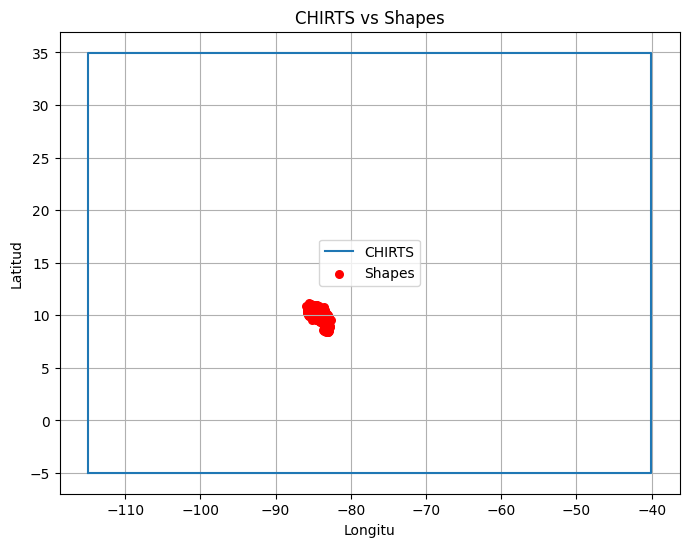

In [15]:
import matplotlib.pyplot as plt

lon_min = float(ds_max.longitude.min())
lon_max = float(ds_max.longitude.max())
lat_min = float(ds_max.latitude.min())
lat_max = float(ds_max.latitude.max())

plt.figure(figsize=(8, 6))

# Draw CHIRTS domain as a rectangle
plt.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    label="CHIRTS",
)

# Plot your points
plt.scatter(points.lon, points.lat, c="red", s=30, label="Shapes")

plt.xlabel("Longitu")
plt.ylabel("Latitud")
plt.legend()
plt.title("CHIRTS vs Shapes")
plt.grid(True)
plt.show()


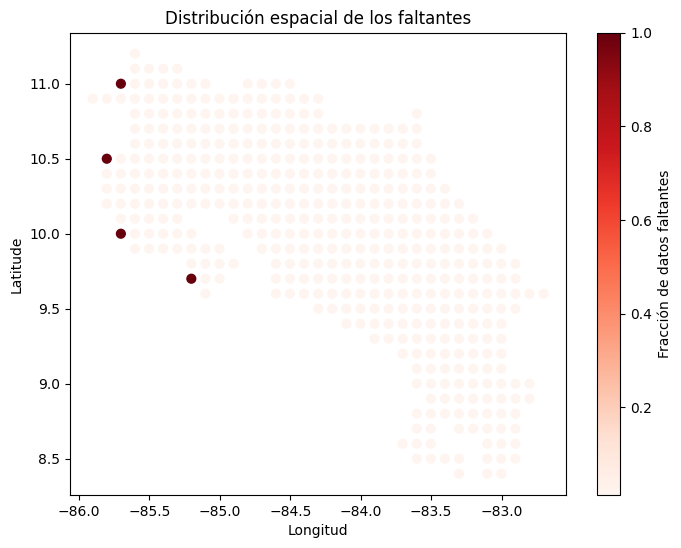

In [17]:

import matplotlib.pyplot as plt
nan_fraction = tmax.isnull().mean("time")

plt.figure(figsize=(8, 6))
plt.scatter(points.lon, points.lat, c=nan_fraction, cmap="Reds", s=40)
plt.colorbar(label="Fracción de datos faltantes")
plt.xlabel("Longitud")
plt.ylabel("Latitude")
plt.title("Distribución espacial de los faltantes")
plt.show()


In [9]:
print("CHIRTS lon:", lon_min, lon_max)
print("CHIRTS lat:", lat_min, lat_max)

print("Points lon:", points.lon.min(), points.lon.max())
print("Points lat:", points.lat.min(), points.lat.max())


CHIRTS lon: -114.97500610351562 -40.02500915527344
CHIRTS lat: -4.975002288818359 34.974998474121094
Points lon: -85.90184900000003 -82.70184900000021
Points lat: 8.398570000000019 11.198570000000007


In [6]:
weekly_max = tmax.resample(time="1W")

weekly_stats_max = xr.Dataset({
    "temp_week_max": weekly_max.max()
})

In [7]:
weekly_stats_max_df = (
    weekly_stats_max
    .to_dataframe()
    .reset_index()
)

points_df = (
    points
    .reset_index()
    .rename(columns={"index": "points"})
)

datos_weekly_max = (
    weekly_stats_max_df
    .merge(points_df, on="points", how="left")
    .rename(columns={"time": "week"})
)

datos_weekly_max = (
    datos_weekly_max
    .drop(columns=["longitude", "latitude"], errors="ignore")
    .rename(columns={"lon": "longitude", "lat": "latitude"})
)


In [8]:
datos_weekly_max.head()

,points,week,temp_week_max,longitude,latitude,canton
0,0,2020-01-05,33.828182,-83.301849,8.39857,Golfito
1,0,2020-01-12,34.763752,-83.301849,8.39857,Golfito
2,0,2020-01-19,35.184273,-83.301849,8.39857,Golfito
3,0,2020-01-26,34.391785,-83.301849,8.39857,Golfito
4,0,2020-02-02,34.843079,-83.301849,8.39857,Golfito


In [ ]:
datos_weekly_max.to_csv(
    "../data/raw/tmax_weekly.csv",
    index=False
)

## Min temp

In [3]:
lonlat = pd.read_csv('../data/raw/locations.csv')

In [4]:
files = sorted(Path("../data/raw/chirts/chirts_min").glob("chirts_tmin_*.nc"))

ds_min = xr.open_mfdataset(
    files,
    engine="netcdf4",
    combine="by_coords",
    parallel=False
)

In [6]:
points = lonlat.reset_index(drop=True)

lons = xr.DataArray(points.lon.values, dims="points")
lats = xr.DataArray(points.lat.values, dims="points")

tmin = ds_min["temp"].interp(
    longitude=("points", points.lon.values),
    latitude=("points", points.lat.values),
    method="nearest"
)

In [7]:
weekly_min = tmin.resample(time="1W")

weekly_stats_min = xr.Dataset({
    "temp_week_min": weekly_min.min()
})

In [8]:
weekly_stats_min_df = (
    weekly_stats_min
    .to_dataframe()
    .reset_index()
)

points_df = (
    points
    .reset_index()
    .rename(columns={"index": "points"})
)

datos_weekly_min = (
    weekly_stats_min_df
    .merge(points_df, on="points", how="left")
    .rename(columns={"time": "week"})
)

datos_weekly_min = (
    datos_weekly_min
    .drop(columns=["longitude", "latitude"], errors="ignore")
    .rename(columns={"lon": "longitude", "lat": "latitude"})
)


In [ ]:
datos_weekly_min.head()

,points,week,temp_week_min,longitude,latitude,canton
0,0,2020-01-05,31.307518,-83.301849,8.39857,Golfito
1,0,2020-01-12,31.340557,-83.301849,8.39857,Golfito
2,0,2020-01-19,32.219620,-83.301849,8.39857,Golfito
3,0,2020-01-26,30.882504,-83.301849,8.39857,Golfito
4,0,2020-02-02,31.125221,-83.301849,8.39857,Golfito


In [9]:
datos_weekly_min.isnull().sum()

points              0
week                0
temp_week_min    1204
longitude           0
latitude            0
canton              0
dtype: int64

In [11]:
print(ds_min.latitude.min().item(), ds_min.latitude.max().item())
print(ds_min.longitude.min().item(), ds_min.longitude.max().item())

print(points.lat.min(), points.lat.max())
print(points.lon.min(), points.lon.max())


-4.975002288818359 34.974998474121094
-114.97500610351562 -40.02500915527344
8.398570000000019 11.198570000000007
-85.90184900000003 -82.70184900000021


In [12]:
ds_min.longitude.values[:5]


array([-114.975006, -114.925   , -114.87501 , -114.825005, -114.775   ],
      dtype=float32)

In [ ]:
datos_weekly_min.to_csv(
    "../data/raw/tmin_weekly.csv",
    index=False
)

In [32]:
ds_min.longitude.min().item(), ds_min.longitude.max().item()


(-114.97500610351562, -40.02500915527344)

In [24]:
points.lon.min(), points.lon.max()

(np.float64(-85.90184900000003), np.float64(-82.70184900000021))